In [ ]:
import pandas as pd

df_train = pd.read_parquet("data/df_train_full.parquet")
df_test = pd.read_parquet("data/df_test_full.parquet")

print(df_train.shape)
print(df_test.shape)

(1385624, 363)
(10, 362)


In [9]:
df_train.head(100)

,case_id,WEEK_NUM,target,month_decision,weekday_decision,year_decision,assignmentdate_238D,assignmentdate_4527235D,birthdate_574D,contractssum_5085716L,...,max_subjectroles_name_838M,max_collater_valueofguarantee_1124L,max_collater_valueofguarantee_876L,max_pmts_month_158T,max_pmts_month_706T,max_pmts_year_1139T,max_pmts_year_507T,max_num_group1_13,max_num_group2_13,age
0,388,1,0,1,1,2019,NaN,NaN,-10880.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2020.0,NaN,1.0,23.0,30
1,405,1,0,1,2,2019,NaN,NaN,-16384.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2020.0,NaN,1.0,35.0,45
2,409,1,0,1,2,2019,NaN,NaN,-9352.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2019.0,NaN,2.0,23.0,26
3,410,1,0,1,2,2019,NaN,NaN,-14831.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2019.0,NaN,0.0,23.0,41
4,411,1,0,1,2,2019,-551.0,NaN,-21741.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2020.0,NaN,3.0,35.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,554,1,0,1,2,2019,-911.0,NaN,-22136.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2020.0,NaN,1.0,23.0,61
96,555,1,0,1,2,2019,NaN,NaN,-19000.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2019.0,NaN,0.0,23.0,52
97,556,1,0,1,2,2019,NaN,NaN,-19699.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2019.0,NaN,1.0,23.0,54
98,559,1,0,1,2,2019,NaN,NaN,-14951.0,NaN,...,ab3c25cf,0.0,NaN,12.0,NaN,2019.0,NaN,1.0,23.0,41


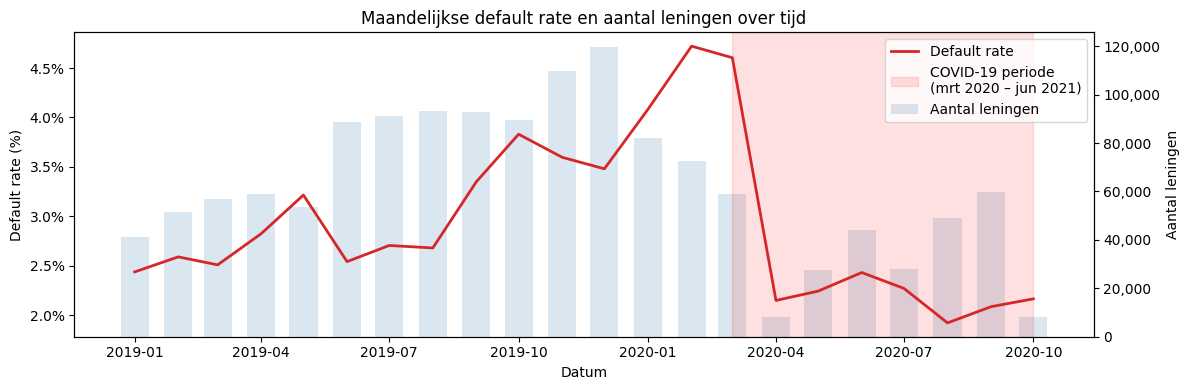

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Build a period column (year-month) and compute monthly default rate
df_train["period"] = pd.to_datetime(
    df_train["year_decision"].astype(str) + "-" + df_train["month_decision"].astype(str).str.zfill(2)
)

monthly = (
    df_train.groupby("period")["target"]
    .agg(default_rate="mean", n="count")
    .reset_index()
    .sort_values("period")
)

# COVID window: March 2020 – June 2021 (capped at last data point)
covid_start = pd.Timestamp("2020-03-01")
covid_end   = min(pd.Timestamp("2021-06-30"), monthly["period"].max())

fig, ax1 = plt.subplots(figsize=(12, 4))

# Bar chart: number of loans (background, secondary axis)
ax2 = ax1.twinx()
ax2.bar(monthly["period"], monthly["n"], width=20, color="steelblue", alpha=0.2, label="Aantal leningen")
ax2.set_ylabel("Aantal leningen")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))

# Line: default rate (foreground, primary axis)
ax1.plot(monthly["period"], monthly["default_rate"] * 100, color="#d62728", linewidth=2, zorder=3, label="Default rate")
ax1.set_xlabel("Datum")
ax1.set_ylabel("Default rate (%)")
ax1.set_title("Maandelijkse default rate en aantal leningen over tijd")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# COVID shading
ax1.axvspan(covid_start, covid_end, color="red", alpha=0.12, label="COVID-19 periode\n(mrt 2020 – jun 2021)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.show()

C:\Users\Vik\AppData\Local\Temp\ipykernel_12272\308052737.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_groep, labels=groepen, showfliers=False, patch_artist=True,


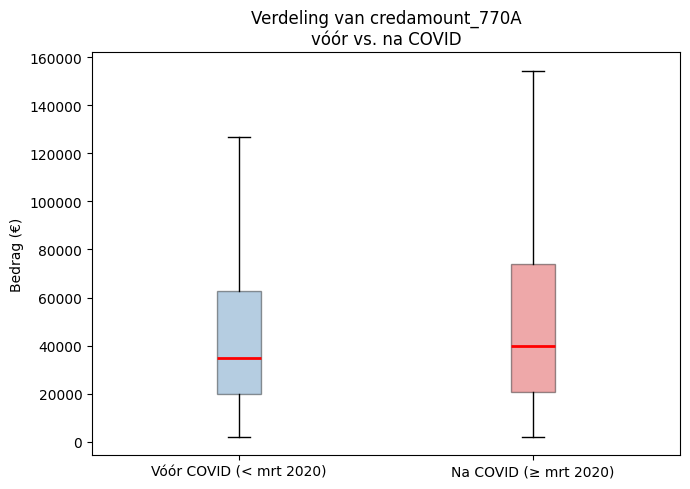

In [7]:
col = "credamount_770A"

if col not in df_train.columns:
    print(f"Column '{col}' not found in df_train.")
else:
    df_box = df_train.dropna(subset=[col]).copy()
    df_box["groep"] = df_box["period"].apply(
        lambda p: "Vóór COVID (< mrt 2020)" if p < pd.Timestamp("2020-03-01") else "Na COVID (≥ mrt 2020)"
    )

    groepen = ["Vóór COVID (< mrt 2020)", "Na COVID (≥ mrt 2020)"]
    data_by_groep = [df_box.loc[df_box["groep"] == g, col].values for g in groepen]

    fig, ax = plt.subplots(figsize=(7, 5))

    bp = ax.boxplot(data_by_groep, labels=groepen, showfliers=False, patch_artist=True,
                    medianprops=dict(color="red", linewidth=2))

    colors = ["steelblue", "#d62728"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    ax.set_ylabel("Bedrag (€)")
    ax.set_title(f"Verdeling van {col}\nvóór vs. na COVID")
    fig.tight_layout()
    plt.show()